In [ ]:
# %% 최근 파일 5개 삭제
import os, glob
from datetime import datetime

OUTPUT_DIR = "./data/7_qwen_test"

files = glob.glob(os.path.join(OUTPUT_DIR, "**", "*.json"), recursive=True)
files_with_mtime = [(f, os.path.getmtime(f)) for f in files]
files_with_mtime.sort(key=lambda x: x[1], reverse=True)

for f, mtime in files_with_mtime[:7]:
    ts = datetime.fromtimestamp(mtime).strftime("%m-%d %H:%M:%S")
    rel = os.path.relpath(f, OUTPUT_DIR)
    os.remove(f)
    print(f"  삭제: {ts} {rel}")

print(f"\n✅ {len(files_with_mtime)}개 삭제 완료")

In [ ]:
"""
동시 텔롭 최대 개수 분석
- 6_telop_instances의 JSON에서 (start_sec, end_sec) 기반으로
  0.1초 bin별 동시 활성 인스턴스 수를 계산
"""
import os
import json
import glob
import numpy as np
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

INST_DIR = "./data/6_telop_instances"
BIN_SIZE = 0.1
NUM_WORKERS = 32


def analyze_one(json_path: str) -> dict:
    """영상 1개의 동시 텔롭 통계"""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    instances = data.get("instances", [])
    if not instances:
        return {"max_simul": 0, "mean_simul": 0.0, "n_instances": 0, "path": json_path}

    # bin별 동시 활성 인스턴스 수
    bins = {}
    for inst in instances:
        s, e = inst["start_sec"], inst["end_sec"]
        b_start = int(s / BIN_SIZE)
        b_end = int(e / BIN_SIZE)
        for b in range(b_start, b_end):
            bins[b] = bins.get(b, 0) + 1

    if not bins:
        return {"max_simul": 0, "mean_simul": 0.0, "n_instances": len(instances), "path": json_path}

    counts = list(bins.values())
    return {
        "max_simul": max(counts),
        "mean_simul": np.mean(counts),
        "n_instances": len(instances),
        "path": json_path,
    }


def main():
    json_paths = sorted(glob.glob(os.path.join(INST_DIR, "**", "*.json"), recursive=True))
    print(f"📁 분석 대상: {len(json_paths):,}개 영상")

    results = []
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as pool:
        futures = {pool.submit(analyze_one, p): p for p in json_paths}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="분석"):
            results.append(fut.result())

    # ── 전체 통계 ──
    max_simuls = np.array([r["max_simul"] for r in results])
    mean_simuls = np.array([r["mean_simul"] for r in results])

    print(f"\n{'='*60}")
    print(f"📊 동시 텔롭 개수 통계 ({len(results):,}개 영상)")
    print(f"{'='*60}")

    print(f"\n  영상별 최대 동시 텔롭 수:")
    print(f"    mean:   {max_simuls.mean():.1f}")
    print(f"    median: {np.median(max_simuls):.1f}")
    print(f"    p90:    {np.percentile(max_simuls, 90):.0f}")
    print(f"    p95:    {np.percentile(max_simuls, 95):.0f}")
    print(f"    p99:    {np.percentile(max_simuls, 99):.0f}")
    print(f"    max:    {max_simuls.max():.0f}")

    print(f"\n  영상별 평균 동시 텔롭 수:")
    nonzero_means = mean_simuls[mean_simuls > 0]
    print(f"    mean:   {nonzero_means.mean():.2f}")
    print(f"    median: {np.median(nonzero_means):.2f}")

    # ── 분포 ──
    print(f"\n  최대 동시 텔롭 수 분포:")
    print(f"    {'구간':<12} {'영상수':>8} {'비율':>8} {'누적':>8}")
    print(f"    {'─'*12} {'─'*8} {'─'*8} {'─'*8}")
    bins_edges = [0, 1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 50, 1000]
    cumul = 0
    for i in range(len(bins_edges) - 1):
        lo, hi = bins_edges[i], bins_edges[i + 1]
        cnt = int(((max_simuls >= lo) & (max_simuls < hi)).sum())
        cumul += cnt
        label = f"{lo}" if hi - lo == 1 else f"{lo}~{hi-1}"
        print(f"    {label:<12} {cnt:>8} {cnt/len(max_simuls)*100:>7.1f}% {cumul/len(max_simuls)*100:>7.1f}%")

    # ── top 10 ──
    print(f"\n  동시 텔롭 최대인 영상 top 10:")
    top10 = sorted(results, key=lambda r: r["max_simul"], reverse=True)[:10]
    for r in top10:
        rel = os.path.relpath(r["path"], INST_DIR)
        print(f"    max={r['max_simul']:>3}  inst={r['n_instances']:>4}  {rel}")

    # ── 채널별 평균 ──
    channel_maxs = {}
    for r in results:
        ch = r["path"].split(os.sep)[-2] if os.sep in r["path"] else "unknown"
        if ch not in channel_maxs:
            channel_maxs[ch] = []
        channel_maxs[ch].append(r["max_simul"])

    ch_avg = {ch: np.mean(vs) for ch, vs in channel_maxs.items()}
    print(f"\n  채널별 평균 최대 동시 텔롭 top 10:")
    for ch, avg in sorted(ch_avg.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"    avg_max={avg:>5.1f}  ({len(channel_maxs[ch]):>3}개 영상)  {ch}")

    # ── K값 제안 ──
    print(f"\n{'='*60}")
    print(f"💡 K값 제안")
    print(f"{'='*60}")
    for p in [90, 95, 99]:
        v = np.percentile(max_simuls, p)
        cover = (max_simuls <= v).sum() / len(max_simuls) * 100
        print(f"  K={int(v):>2} → {cover:.1f}% 영상 커버 (p{p})")


if __name__ == "__main__":
    main()

In [ ]:
# %% 텔롭 인스턴스 수 분포 확인
import os
import numpy as np
import polars as pl
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

INST_DIR = "./data/6_telop_instances"


def analyze_one(args):
    channel, fname = args
    path = os.path.join(INST_DIR, channel, fname)
    try:
        df = pl.read_parquet(path, glob=False)
    except Exception:
        return None

    n_total = len(df)
    if n_total == 0:
        return {"n_total": 0, "max_concurrent": 0, "channel": channel}

    # 같은 시점 최대 공존 개수 (sweep line)
    events = []
    for row in df.iter_rows(named=True):
        events.append((float(row["start_sec"]), 1))
        events.append((float(row["end_sec"]), -1))
    events.sort(key=lambda x: (x[0], -x[1]))  # 같은 시각이면 시작이 먼저

    cur = 0
    mx = 0
    for _, d in events:
        cur += d
        mx = max(mx, cur)

    return {"n_total": n_total, "max_concurrent": mx, "channel": channel}


# 태스크 수집
tasks = []
for channel in sorted(os.listdir(INST_DIR)):
    ch_dir = os.path.join(INST_DIR, channel)
    if not os.path.isdir(ch_dir):
        continue
    for fname in os.listdir(ch_dir):
        if fname.endswith(".parquet"):
            tasks.append((channel, fname))

print(f"🎯 분석 대상: {len(tasks):,}개 영상")

# 병렬 실행
results = []
with ProcessPoolExecutor(max_workers=32) as pool:
    futures = [pool.submit(analyze_one, t) for t in tasks]
    for fut in tqdm(as_completed(futures), total=len(futures), desc="분석"):
        r = fut.result()
        if r is not None:
            results.append(r)

# 집계
totals = np.array([r["n_total"] for r in results])
concurrents = np.array([r["max_concurrent"] for r in results])

def summary(arr, name):
    print(f"\n📊 {name}")
    print(f"  mean:   {arr.mean():.1f}")
    print(f"  median: {np.median(arr):.0f}")
    print(f"  std:    {arr.std():.1f}")
    print(f"  min:    {arr.min()}")
    print(f"  max:    {arr.max()}")
    print(f"  p90:    {np.percentile(arr, 90):.0f}")
    print(f"  p95:    {np.percentile(arr, 95):.0f}")
    print(f"  p99:    {np.percentile(arr, 99):.0f}")
    print(f"  p99.9:  {np.percentile(arr, 99.9):.0f}")


summary(totals, "영상당 총 텔롭 인스턴스 수")
summary(concurrents, "영상당 동시 공존 최대 인스턴스 수")

# 구간별 분포
print(f"\n📊 영상당 총 인스턴스 수 구간 분포")
bins = [0, 10, 50, 100, 200, 500, 1000, 2000, 5000, 100000]
for lo, hi in zip(bins[:-1], bins[1:]):
    n = ((totals >= lo) & (totals < hi)).sum()
    pct = n / len(totals) * 100
    print(f"  {lo:>5}~{hi:<6}: {n:>6,} ({pct:>5.1f}%)")

print(f"\n📊 동시 공존 최대 개수 구간 분포")
bins_c = [0, 5, 10, 20, 50, 100, 200, 500, 10000]
for lo, hi in zip(bins_c[:-1], bins_c[1:]):
    n = ((concurrents >= lo) & (concurrents < hi)).sum()
    pct = n / len(concurrents) * 100
    print(f"  {lo:>4}~{hi:<6}: {n:>6,} ({pct:>5.1f}%)")

# 채널별 평균도 같이 보기 (어떤 채널이 텔롭을 많이 쓰는지)
from collections import defaultdict
by_ch = defaultdict(list)
for r in results:
    by_ch[r["channel"]].append(r["n_total"])

ch_means = [(ch, np.mean(v)) for ch, v in by_ch.items()]
ch_means.sort(key=lambda x: -x[1])
print(f"\n📊 영상 평균 인스턴스 수 top/bottom 10 채널")
print("  [TOP 10]")
for ch, m in ch_means[:10]:
    print(f"    {ch:40s} {m:7.1f}")
print("  [BOTTOM 10]")
for ch, m in ch_means[-10:]:
    print(f"    {ch:40s} {m:7.1f}")

In [1]:
# %% 데이터 용량 확인
import os
from tqdm import tqdm

def get_dir_size(path):
    total = 0
    files = []
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            files.append(os.path.join(dirpath, f))
    for fp in tqdm(files, desc=os.path.basename(path)):
        total += os.path.getsize(fp)
    return total

dirs = {
    "8_telop_position": "./data/8_telop_position",
    "4_stt_results": "./data/4_stt_results",
}
files = {
    "8_text_embeddings.pt": "./data/8_text_embeddings.pt",
}

total = 0
for name, path in dirs.items():
    if os.path.exists(path):
        size = get_dir_size(path)
        total += size
        print(f"📁 {name}: {size / 1e9:.2f} GB\n")

for name, path in files.items():
    if os.path.exists(path):
        size = os.path.getsize(path)
        total += size
        print(f"📄 {name}: {size / 1e9:.2f} GB")

print(f"\n📊 합계: {total / 1e9:.2f} GB")

8_telop_position: 100%|██████████| 66400/66400 [00:05<00:00, 12288.88it/s] 


📁 8_telop_position: 1.00 GB



4_stt_results: 100%|██████████| 66400/66400 [00:15<00:00, 4292.93it/s]

📁 4_stt_results: 0.17 GB

📄 8_text_embeddings.pt: 9.11 GB

📊 합계: 10.29 GB


In [1]:
# 확인용 셀 (단독 실행)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.attention import sdpa_kernel, SDPBackend

device = torch.device("cuda")

# 간단한 테스트용 attention
d_model = 256
n_heads = 8
head_dim = d_model // n_heads

q = torch.randn(4, 6400, d_model, device=device, dtype=torch.bfloat16)
k = torch.randn(4, 6400, d_model, device=device, dtype=torch.bfloat16)
v = torch.randn(4, 6400, d_model, device=device, dtype=torch.bfloat16)

q = q.reshape(4, 6400, n_heads, head_dim).transpose(1, 2)
k = k.reshape(4, 6400, n_heads, head_dim).transpose(1, 2)
v = v.reshape(4, 6400, n_heads, head_dim).transpose(1, 2)

# 1. mask 없이 (windowed self-attn의 non-shifted layer)
print("=== mask 없음 (non-shifted window) ===")
try:
    with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
        out = F.scaled_dot_product_attention(q, k, v)
    print("✅ Flash Attention 사용 가능")
except RuntimeError as e:
    print(f"❌ Flash Attention 불가: {e}")

# 2. mask 있을 때 (shifted window)
print("\n=== mask 있음 (shifted window) ===")
mask = torch.zeros(4, n_heads, 6400, 6400, device=device, dtype=torch.bfloat16)
try:
    with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
    print("✅ Flash Attention 사용 가능")
except RuntimeError as e:
    print(f"❌ Flash Attention 불가: {e}")

try:
    with sdpa_kernel(SDPBackend.EFFICIENT_ATTENTION):
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
    print("✅ Memory Efficient Attention 사용 가능")
except RuntimeError as e:
    print(f"❌ Memory Efficient 불가: {e}")

# 3. cross-attention (6400 query × 9 key)
print("\n=== cross-attention (6400×9) ===")
k_cross = torch.randn(4, 9, d_model, device=device, dtype=torch.bfloat16)
v_cross = torch.randn(4, 9, d_model, device=device, dtype=torch.bfloat16)
k_cross = k_cross.reshape(4, 9, n_heads, head_dim).transpose(1, 2)
v_cross = v_cross.reshape(4, 9, n_heads, head_dim).transpose(1, 2)

try:
    with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
        out = F.scaled_dot_product_attention(q, k_cross, v_cross)
    print("✅ Flash Attention 사용 가능")
except RuntimeError as e:
    print(f"❌ Flash Attention 불가: {e}")

=== mask 없음 (non-shifted window) ===
✅ Flash Attention 사용 가능

=== mask 있음 (shifted window) ===
❌ Flash Attention 불가: No available kernel. Aborting execution.
✅ Memory Efficient Attention 사용 가능

=== cross-attention (6400×9) ===
✅ Flash Attention 사용 가능


/tmp/ipykernel_1962150/3138312088.py:36: UserWarning: Memory efficient kernel not used because: (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:915.)
  out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
/tmp/ipykernel_1962150/3138312088.py:36: UserWarning: Memory Efficient attention has been runtime disabled. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/sdp_utils_cpp.h:552.)
  out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
/tmp/ipykernel_1962150/3138312088.py:36: UserWarning: Flash attention kernel not used because: (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:917.)
  out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
/tmp/ipykernel_1962150/3138312088.py:36: UserWarning: Flash Attention does not support non-null attn_mask. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/sdp_utils_cpp.h:262.)
  out = F.scaled_dot_product_attenti

In [2]:
"""
ViT Patch Mask 모델 하이퍼파라미터 결정을 위한 데이터 분포 확인
- duration / frame 수 분포
- 프레임별 동시 활성 텔롭 수 분포
- 텔롭 text_len 분포
실행: python check_data_dist.py
"""
import os, json
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

POS_DIR = "./data/8_telop_position"
NUM_WORKERS = 32
FPS = 10
GRID_W = 80
GRID_H = 80


def analyze_one(args):
    channel, path = args
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    instances = data.get("instances", [])
    duration = data.get("duration", 0.1)
    if instances:
        duration = max(duration, max(inst["end_sec"] for inst in instances))

    n_inst = len(instances)
    if n_inst == 0:
        return {
            "duration": duration,
            "n_inst": 0,
            "max_concurrent": 0,
            "text_lens": [],
        }

    starts = np.array([inst["start_sec"] for inst in instances])
    ends = np.array([inst["end_sec"] for inst in instances])
    text_lens = [len(inst["text"]) for inst in instances]

    # 프레임별 동시 활성 텔롭 수
    n_frames = int(duration * FPS) + 1
    times = np.arange(n_frames, dtype=np.float32) / FPS
    active_matrix = (starts[None, :] <= times[:, None] + 0.05) & (ends[None, :] > times[:, None])
    concurrent_counts = active_matrix.sum(axis=1)
    max_concurrent = int(concurrent_counts.max())

    return {
        "duration": duration,
        "n_inst": n_inst,
        "max_concurrent": max_concurrent,
        "text_lens": text_lens,
    }


def main():
    # ── 파일 목록 수집 (셀 1과 동일한 방식) ──
    json_paths = []
    for channel in sorted(os.listdir(POS_DIR)):
        ch_dir = os.path.join(POS_DIR, channel)
        if not os.path.isdir(ch_dir):
            continue
        for fname in sorted(os.listdir(ch_dir)):
            if fname.endswith(".json"):
                json_paths.append((channel, os.path.join(ch_dir, fname)))

    print(f"📁 분석 대상: {len(json_paths):,}개 영상\n")

    results = []
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as pool:
        futures = {pool.submit(analyze_one, args): args for args in json_paths}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="분석"):
            results.append(fut.result())

    # ── duration / frame 수 ──
    durations = np.array([r["duration"] for r in results])
    frame_counts = (durations * FPS).astype(int) + 1

    print(f"\n{'='*60}")
    print(f"📊 duration (초)")
    print(f"  mean: {durations.mean():.1f}  median: {np.median(durations):.1f}")
    print(f"  p95:  {np.percentile(durations, 95):.1f}")
    print(f"  p99:  {np.percentile(durations, 99):.1f}")
    print(f"  max:  {durations.max():.1f}")

    print(f"\n📊 frame 수 (FPS={FPS})")
    print(f"  mean: {frame_counts.mean():.0f}  median: {np.median(frame_counts):.0f}")
    print(f"  p95:  {np.percentile(frame_counts, 95):.0f}")
    print(f"  p99:  {np.percentile(frame_counts, 99):.0f}")
    print(f"  max:  {frame_counts.max()}")

    # ── 동시 활성 텔롭 수 ──
    max_concurrents = np.array([r["max_concurrent"] for r in results])

    print(f"\n📊 프레임별 동시 활성 텔롭 수 (영상별 max)")
    print(f"  mean: {max_concurrents.mean():.1f}  median: {np.median(max_concurrents):.0f}")
    print(f"  p95:  {np.percentile(max_concurrents, 95):.0f}")
    print(f"  p99:  {np.percentile(max_concurrents, 99):.0f}")
    print(f"  max:  {max_concurrents.max()}")

    # ── 텔롭 text_len ──
    all_text_lens = []
    for r in results:
        all_text_lens.extend(r["text_lens"])
    all_text_lens = np.array(all_text_lens) if all_text_lens else np.array([0])

    print(f"\n📊 텔롭 text_len (글자 수)")
    print(f"  mean: {all_text_lens.mean():.1f}  median: {np.median(all_text_lens):.1f}")
    print(f"  p95:  {np.percentile(all_text_lens, 95):.0f}")
    print(f"  p99:  {np.percentile(all_text_lens, 99):.0f}")
    print(f"  max:  {all_text_lens.max()}")

    # ── 인스턴스 수 ──
    n_insts = np.array([r["n_inst"] for r in results])

    print(f"\n📊 영상별 인스턴스 수")
    print(f"  mean: {n_insts.mean():.1f}  median: {np.median(n_insts):.0f}")
    print(f"  p95:  {np.percentile(n_insts, 95):.0f}")
    print(f"  p99:  {np.percentile(n_insts, 99):.0f}")
    print(f"  max:  {n_insts.max()}")

    # ── 하이퍼파라미터 제안 ──
    print(f"\n{'='*60}")
    print(f"📌 하이퍼파라미터 제안 (max 기준)")
    print(f"  MAX_FRAMES   = {int(frame_counts.max())}")
    print(f"  K_TELOP_FEAT = {int(max_concurrents.max())}")
    print(f"  FEAT_DIM     = 2 + {int(max_concurrents.max())} = {2 + int(max_concurrents.max())}")
    print(f"  text_len 정규화 = / {int(all_text_lens.max())}")


if __name__ == "__main__":
    main()

📁 분석 대상: 66,400개 영상



분석: 100%|██████████| 66400/66400 [00:04<00:00, 16263.85it/s]



📊 duration (초)
  mean: 41.6  median: 40.9
  p95:  67.6
  p99:  126.8
  max:  180.2

📊 frame 수 (FPS=10)
  mean: 417  median: 410
  p95:  677
  p99:  1269
  max:  1803

📊 프레임별 동시 활성 텔롭 수 (영상별 max)
  mean: 5.8  median: 5
  p95:  14
  p99:  24
  max:  138

📊 텔롭 text_len (글자 수)
  mean: 6.4  median: 4.0
  p95:  18
  p99:  30
  max:  169

📊 영상별 인스턴스 수
  mean: 56.3  median: 29
  p95:  194
  p99:  403
  max:  4251

📌 하이퍼파라미터 제안 (max 기준)
  MAX_FRAMES   = 1803
  K_TELOP_FEAT = 138
  FEAT_DIM     = 2 + 138 = 140
  text_len 정규화 = / 169


  로고 (작음): w=8 h=2 min_dim=2 sigma=0.80
  자막 (중간): w=30 h=3 min_dim=3 sigma=1.90
  제목 (큼): w=50 h=6 min_dim=6 sigma=3.46


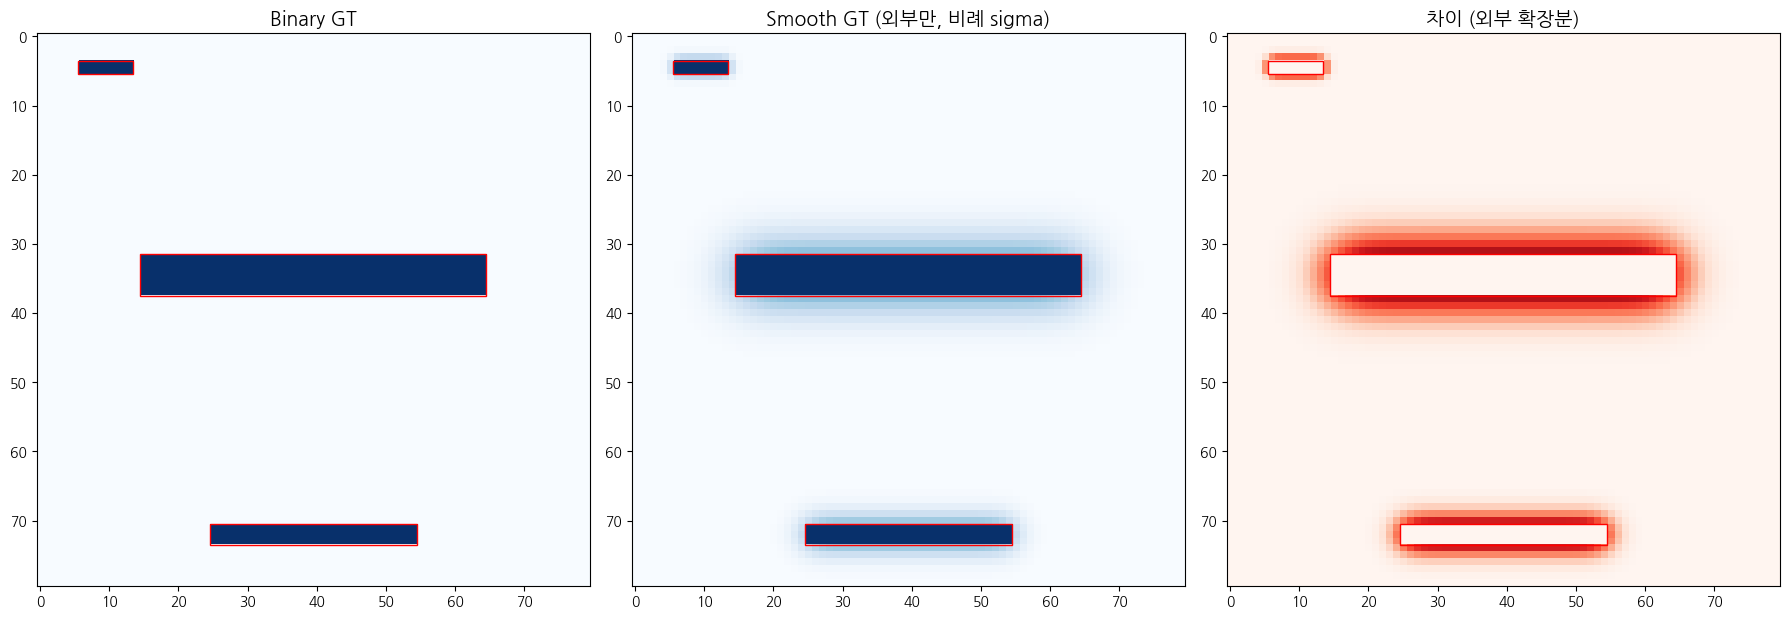

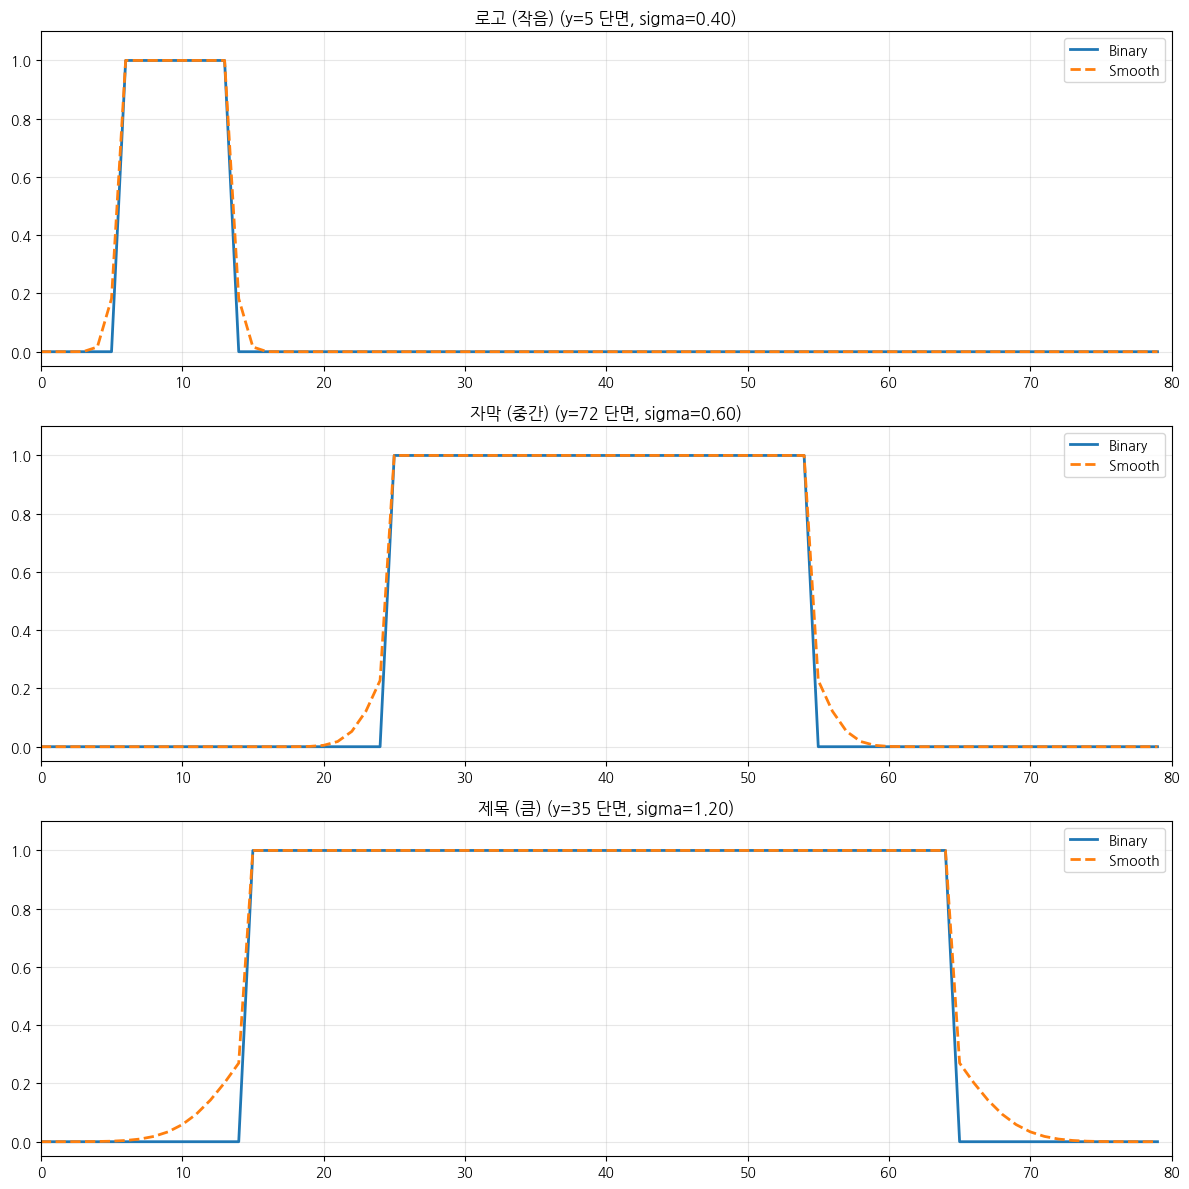


📊 외부 확장 통계
  확장 셀: 3140개 (49.1%)
  값 범위: 0.000 ~ 0.413
  값 평균: 0.061


In [11]:
# %% label smoothing 시각화 (외부만 smoothing, 비례 sigma)
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

plt.rc('font', family='NanumGothic')

GRID_H, GRID_W = 80, 80

telops = [
    {"name": "로고 (작음)", "cx": 10, "cy": 5, "w": 8, "h": 2},
    {"name": "자막 (중간)", "cx": 40, "cy": 72, "w": 30, "h": 3},
    {"name": "제목 (큼)",   "cx": 40, "cy": 35, "w": 50, "h": 6},
]

# ── binary mask ──
binary = np.zeros((GRID_H, GRID_W), dtype=np.float32)
for t in telops:
    x0 = max(0, t["cx"] - t["w"] // 2)
    y0 = max(0, t["cy"] - t["h"] // 2)
    x1 = min(GRID_W, x0 + t["w"])
    y1 = min(GRID_H, y0 + t["h"])
    binary[y0:y1, x0:x1] = 1.0

# ── smooth mask (외부만, 비례 sigma) ──
smooth = np.zeros((GRID_H, GRID_W), dtype=np.float32)
for t in telops:
    x0 = max(0, t["cx"] - t["w"] // 2)
    y0 = max(0, t["cy"] - t["h"] // 2)
    x1 = min(GRID_W, x0 + t["w"])
    y1 = min(GRID_H, y0 + t["h"])

    single = np.zeros((GRID_H, GRID_W), dtype=np.float32)
    single[y0:y1, x0:x1] = 1.0

    min_dim = min(t["w"], t["h"])
    sigma = np.sqrt(t["w"] * t["h"]) * 0.2


    blurred = gaussian_filter(single, sigma=sigma)
    merged = np.maximum(single, blurred)

    smooth = np.maximum(smooth, merged)
    print(f"  {t['name']}: w={t['w']} h={t['h']} min_dim={min_dim} sigma={sigma:.2f}")

# ── 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

axes[0].imshow(binary, cmap="Blues", vmin=0, vmax=1, origin="upper")
axes[0].set_title("Binary GT", fontsize=14)

axes[1].imshow(smooth, cmap="Blues", vmin=0, vmax=1, origin="upper")
axes[1].set_title("Smooth GT (외부만, 비례 sigma)", fontsize=14)

diff = smooth - binary
axes[2].imshow(diff, cmap="Reds", vmin=0, vmax=0.5, origin="upper")
axes[2].set_title("차이 (외부 확장분)", fontsize=14)

for ax in axes:
    for t in telops:
        x0 = max(0, t["cx"] - t["w"] // 2)
        y0 = max(0, t["cy"] - t["h"] // 2)
        rect = plt.Rectangle((x0-0.5, y0-0.5), t["w"], t["h"],
                              linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    ax.set_xlim(-0.5, GRID_W-0.5)
    ax.set_ylim(GRID_H-0.5, -0.5)

plt.tight_layout()
plt.savefig("./label_smoothing_proportional.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 텔롭별 단면 ──
fig2, axes2 = plt.subplots(len(telops), 1, figsize=(12, 4*len(telops)))
for i, t in enumerate(telops):
    cy = t["cy"]
    axes2[i].plot(binary[cy, :], label="Binary", linewidth=2)
    axes2[i].plot(smooth[cy, :], label="Smooth", linewidth=2, linestyle="--")
    axes2[i].set_title(f"{t['name']} (y={cy} 단면, sigma={max(0.3, min(t['w'],t['h'])*0.2):.2f})", fontsize=12)
    axes2[i].set_xlim(0, GRID_W)
    axes2[i].set_ylim(-0.05, 1.1)
    axes2[i].legend()
    axes2[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./label_smoothing_cross_section.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 통계 ──
ext = smooth - binary
ext_nonzero = ext[ext > 0]
print(f"\n📊 외부 확장 통계")
print(f"  확장 셀: {len(ext_nonzero)}개 ({len(ext_nonzero)/(GRID_H*GRID_W)*100:.1f}%)")
print(f"  값 범위: {ext_nonzero.min():.3f} ~ {ext_nonzero.max():.3f}")
print(f"  값 평균: {ext_nonzero.mean():.3f}")

In [1]:
# %% 셀 1: 데이터 로드 (텔롭 bbox 예측 모델)
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import polars as pl
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

POS_DIR = "./data/8_telop_position"
STT_DIR = "./data/4_stt_results"
EMB_PATH = "./data/8_text_embeddings.pt"
HEATMAP_DIR = "./data/8_heatmap"
GRID_W = 80
GRID_H = 80
EVAL_PER_CHANNEL = 5
SEED = 42
NUM_WORKERS = 32
FPS = 10
MAX_FRAMES = 2000
MAX_ACTIVE_PER_FRAME = 150
MAX_TEXT_LEN = 200
SLOT_DIM = 5
TIME_DIM = 3

text2emb = torch.load(EMB_PATH, weights_only=True)
EMB_DIM = next(iter(text2emb.values())).shape[0]
ZERO_EMB = torch.zeros(EMB_DIM)
print(f"✅ 임베딩 로드: {len(text2emb):,}개  |  dim={EMB_DIM}")


def stt_frames_to_segments(df_stt):
    rows = df_stt.sort("frame_num").to_dicts()
    segments = []
    cur_text = None
    cur_start_frame = None
    prev_frame = None
    for r in rows:
        t = r["stt_text"]
        f = int(r["frame_num"])
        if t != cur_text:
            if cur_text is not None and cur_text != "":
                segments.append({
                    "start": cur_start_frame / FPS,
                    "end": (prev_frame + 1) / FPS,
                    "text": cur_text.strip(),
                })
            cur_text = t
            cur_start_frame = f
        prev_frame = f
    if cur_text is not None and cur_text != "":
        segments.append({
            "start": cur_start_frame / FPS,
            "end": (prev_frame + 1) / FPS,
            "text": cur_text.strip(),
        })
    return segments


def load_one(args):
    channel, path = args
    with open(path, "r") as f:
        data = json.load(f)
    instances = data.get("instances", [])
    duration = data.get("duration", 0.1)
    if instances:
        duration = max(duration, max(inst["end_sec"] for inst in instances))
    video_name = data.get("video", "")
    file_id = os.path.basename(path)[:-5]
    inst_list = []
    for inst in instances:
        gx = int(np.clip(round(inst["grid_x"]), 0, GRID_W - 1))
        gy = int(np.clip(round(inst["grid_y"]), 0, GRID_H - 1))
        gw = int(np.clip(round(inst["grid_w"]), 1, GRID_W))
        gh = int(np.clip(round(inst["grid_h"]), 1, GRID_H))
        inst_list.append({
            "text": inst["text"],
            "text_len": len(inst["text"]),
            "start": inst["start_sec"],
            "end": inst["end_sec"],
            "x": gx, "y": gy, "w": gw, "h": gh,
        })
    stt_path = os.path.join(STT_DIR, channel, file_id + ".parquet")
    stt_segments = []
    if os.path.exists(stt_path):
        try:
            df_stt = pl.read_parquet(stt_path, glob=False)
            stt_segments = stt_frames_to_segments(df_stt)
        except:
            pass
    return {
        "channel": channel,
        "video_name": video_name,
        "file_id": file_id,
        "instances": inst_list,
        "stt_segments": stt_segments,
        "duration": duration,
    }


json_paths = []
for channel in sorted(os.listdir(POS_DIR)):
    ch_dir = os.path.join(POS_DIR, channel)
    if not os.path.isdir(ch_dir):
        continue
    for fname in sorted(os.listdir(ch_dir)):
        if fname.endswith(".json"):
            json_paths.append((channel, os.path.join(ch_dir, fname)))

samples = []
channel_set = set()
with ProcessPoolExecutor(max_workers=NUM_WORKERS) as pool:
    futures = {pool.submit(load_one, args): args for args in json_paths}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="로드"):
        result = fut.result()
        channel_set.add(result["channel"])
        samples.append(result)

channels = sorted(channel_set)
channel2id = {ch: i for i, ch in enumerate(channels)}

rng = random.Random(SEED)
by_channel = {}
for s in samples:
    if s["channel"] not in by_channel:
        by_channel[s["channel"]] = []
    by_channel[s["channel"]].append(s)

train_samples = []
eval_samples = []
for ch, ch_samples in by_channel.items():
    ch_samples.sort(key=lambda s: s["file_id"])
    rng.shuffle(ch_samples)
    n_eval = min(EVAL_PER_CHANNEL, len(ch_samples))
    eval_samples.extend(ch_samples[:n_eval])
    train_samples.extend(ch_samples[n_eval:])

train_samples = [s for s in train_samples if len(s["instances"]) > 0]
eval_samples_with = [s for s in eval_samples if len(s["instances"]) > 0]

print(f"✅ 채널: {len(channels)}개")
print(f"   train: {len(train_samples):,}  eval: {len(eval_samples_with):,}")

✅ 임베딩 로드: 2,167,019개  |  dim=1024


로드: 100%|██████████| 66400/66400 [00:10<00:00, 6325.78it/s]


✅ 채널: 664개
   train: 56,892  eval: 2,984


In [2]:
norms = torch.stack([v.norm() for v in text2emb.values()])
print(f"embedding norm: mean={norms.mean():.4f}  std={norms.std():.4f}  min={norms.min():.4f}  max={norms.max():.4f}")

embedding norm: mean=107.2592  std=2.1827  min=62.8623  max=158.4233


In [1]:
# %% 셀 1: 데이터 로드 + instance feature 추출
import os, json, random, hashlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import polars as pl
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

POS_DIR = "./data/8_telop_position"
STT_DIR = "./data/4_stt_results"
EMB_PATH = "./data/8_text_embeddings.pt"
GRID_W = 80
GRID_H = 80
EVAL_PER_CHANNEL = 5
SEED = 42
NUM_WORKERS = 32
FPS = 10
MAX_TEXT_LEN = 200
MAX_ACTIVE_PER_FRAME = 150

# ── 임베딩 로드 ──
text2emb = torch.load(EMB_PATH, weights_only=True)
EMB_DIM = next(iter(text2emb.values())).shape[0]
ZERO_EMB = torch.zeros(EMB_DIM)
print(f"✅ 임베딩 로드: {len(text2emb):,}개  |  dim={EMB_DIM}")


def stt_frames_to_segments(df_stt):
    rows = df_stt.sort("frame_num").to_dicts()
    segments = []
    cur_text = None
    cur_start_frame = None
    prev_frame = None
    for r in rows:
        t = r["stt_text"]
        f = int(r["frame_num"])
        if t != cur_text:
            if cur_text is not None and cur_text != "":
                segments.append({
                    "start": cur_start_frame / FPS,
                    "end": (prev_frame + 1) / FPS,
                    "text": cur_text.strip(),
                })
            cur_text = t
            cur_start_frame = f
        prev_frame = f
    if cur_text is not None and cur_text != "":
        segments.append({
            "start": cur_start_frame / FPS,
            "end": (prev_frame + 1) / FPS,
            "text": cur_text.strip(),
        })
    return segments


def load_one(args):
    channel, path = args
    with open(path, "r") as f:
        data = json.load(f)
    instances = data.get("instances", [])
    duration = data.get("duration", 0.1)
    if instances:
        duration = max(duration, max(inst["end_sec"] for inst in instances))
    video_name = data.get("video", "")
    file_id = os.path.basename(path)[:-5]
    inst_list = []
    for inst in instances:
        gx = int(np.clip(round(inst["grid_x"]), 0, GRID_W - 1))
        gy = int(np.clip(round(inst["grid_y"]), 0, GRID_H - 1))
        gw = int(np.clip(round(inst["grid_w"]), 1, GRID_W))
        gh = int(np.clip(round(inst["grid_h"]), 1, GRID_H))
        inst_list.append({
            "text": inst["text"],
            "text_len": len(inst["text"]),
            "start": inst["start_sec"],
            "end": inst["end_sec"],
            "x": gx, "y": gy, "w": gw, "h": gh,
        })
    fname = os.path.basename(path)[:-5]
    stt_path = os.path.join(STT_DIR, channel, fname + ".parquet")
    stt_segments = []
    if os.path.exists(stt_path):
        try:
            df_stt = pl.read_parquet(stt_path, glob=False)
            stt_segments = stt_frames_to_segments(df_stt)
        except:
            pass
    return {
        "channel": channel,
        "video_name": video_name,
        "file_id": file_id,
        "instances": inst_list,
        "stt_segments": stt_segments,
        "duration": duration,
    }


json_paths = []
for channel in sorted(os.listdir(POS_DIR)):
    ch_dir = os.path.join(POS_DIR, channel)
    if not os.path.isdir(ch_dir):
        continue
    for fname in sorted(os.listdir(ch_dir)):
        if fname.endswith(".json"):
            json_paths.append((channel, os.path.join(ch_dir, fname)))

samples = []
channel_set = set()
with ProcessPoolExecutor(max_workers=NUM_WORKERS) as pool:
    futures = {pool.submit(load_one, args): args for args in json_paths}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="로드"):
        result = fut.result()
        channel_set.add(result["channel"])
        samples.append(result)

channels = sorted(channel_set)
channel2id = {ch: i for i, ch in enumerate(channels)}

# ── train/eval 분리 ──
rng = random.Random(SEED)
by_channel = {}
for s in samples:
    if s["channel"] not in by_channel:
        by_channel[s["channel"]] = []
    by_channel[s["channel"]].append(s)

eval_file_ids = set()
eval_samples = []
train_samples = []
for ch, ch_samples in by_channel.items():
    ch_samples.sort(key=lambda s: s["file_id"])
    rng.shuffle(ch_samples)
    n_eval = min(EVAL_PER_CHANNEL, len(ch_samples))
    for s in ch_samples[:n_eval]:
        eval_file_ids.add((s["channel"], s["file_id"]))
        eval_samples.append(s)
    train_samples.extend(ch_samples[n_eval:])

print(f"✅ train 영상: {len(train_samples):,}  eval 영상: {len(eval_samples):,}")


# ── instance feature 추출 ──
def extract_instance_features(sample):
    """영상의 각 instance에 대해 feature dict를 반환"""
    channel = sample["channel"]
    duration = max(sample["duration"], 0.1)
    instances = sample["instances"]
    n_inst = len(instances)
    if n_inst == 0:
        return []

    inst_starts = np.array([inst["start"] for inst in instances])
    inst_ends   = np.array([inst["end"]   for inst in instances])
    inst_tlens  = np.array([inst["text_len"] for inst in instances])

    channel_emb = F.normalize(text2emb.get(channel, ZERO_EMB), dim=-1)
    video_emb   = F.normalize(text2emb.get(sample["video_name"], ZERO_EMB), dim=-1)
    inst_embs   = torch.stack([text2emb.get(inst["text"], ZERO_EMB) for inst in instances])
    inst_embs   = F.normalize(inst_embs, dim=-1)

    ch_sims  = F.cosine_similarity(inst_embs, channel_emb.unsqueeze(0), dim=-1).numpy()
    vid_sims = F.cosine_similarity(inst_embs, video_emb.unsqueeze(0), dim=-1).numpy()

    stt_sims = np.zeros(n_inst, dtype=np.float32)
    has_stts = np.zeros(n_inst, dtype=np.float32)
    stt_segments = sample["stt_segments"]
    if len(stt_segments) > 0:
        stt_starts = np.array([seg["start"] for seg in stt_segments])
        stt_ends   = np.array([seg["end"]   for seg in stt_segments])
        stt_embs_raw = torch.stack([text2emb.get(seg["text"], ZERO_EMB) for seg in stt_segments])
        stt_embs = F.normalize(stt_embs_raw, dim=-1)
        for i in range(n_inst):
            mid = (inst_starts[i] + inst_ends[i]) / 2
            stt_active = (stt_starts <= mid) & (stt_ends > mid)
            stt_active_idx = np.where(stt_active)[0]
            if len(stt_active_idx) > 0:
                stt_sims[i] = F.cosine_similarity(
                    inst_embs[i].unsqueeze(0), stt_embs[stt_active_idx[0]].unsqueeze(0)).item()
                has_stts[i] = 1.0

    # avg_coactive
    n_frames = max(1, min(int(duration * FPS) + 1, 2000))
    times = np.arange(n_frames, dtype=np.float32) / FPS
    active_matrix = (inst_starts[None, :] <= times[:, None] + 0.05) & \
                    (inst_ends[None, :] > times[:, None])
    co_active_per_frame = active_matrix.sum(axis=1)
    inst_avg_coactive = np.zeros(n_inst, dtype=np.float32)
    for i in range(n_inst):
        frames_i = active_matrix[:, i]
        if frames_i.any():
            inst_avg_coactive[i] = co_active_per_frame[frames_i].mean()

    results = []
    for i in range(n_inst):
        inst = instances[i]
        cx, cy = int(inst["x"]), int(inst["y"])
        w, h = int(inst["w"]), int(inst["h"])
        x0 = max(0, cx - w // 2)
        y0 = max(0, cy - h // 2)
        x1 = min(GRID_W, x0 + w)
        y1 = min(GRID_H, y0 + h)

        results.append({
            "channel": channel,
            "channel_id": channel2id[channel],
            "text_len": inst_tlens[i] / MAX_TEXT_LEN,
            "ch_sim": ch_sims[i],
            "vid_sim": vid_sims[i],
            "stt_sim": stt_sims[i],
            "has_stt": has_stts[i],
            "start_norm": inst_starts[i] / duration,
            "end_norm": inst_ends[i] / duration,
            "dur_norm": (inst_ends[i] - inst_starts[i]) / duration,
            "avg_coactive": inst_avg_coactive[i] / MAX_ACTIVE_PER_FRAME,
            "emb": inst_embs[i],  # (1024,)
            "x0": x0, "y0": y0, "x1": x1, "y1": y1,
        })
    return results


print("\n인스턴스 feature 추출 중...")
train_instances = []
for s in tqdm(train_samples, desc="train"):
    train_instances.extend(extract_instance_features(s))

eval_instances = []
for s in tqdm(eval_samples, desc="eval"):
    eval_instances.extend(extract_instance_features(s))

print(f"\n✅ train instances: {len(train_instances):,}")
print(f"   eval instances:  {len(eval_instances):,}")

✅ 임베딩 로드: 2,167,019개  |  dim=1024


로드: 100%|██████████| 66400/66400 [00:10<00:00, 6396.31it/s]


✅ train 영상: 63,080  eval 영상: 3,320

인스턴스 feature 추출 중...


eval: 100%|██████████| 3320/3320 [00:05<00:00, 621.80it/s]


✅ train instances: 3,561,083
   eval instances:  180,019


In [2]:
# %% 셀 2: nearest-neighbor upper bound (faiss 없이)

def make_feature_vec(inst, use_emb=True):
    scalars = np.array([
        inst["text_len"],
        inst["ch_sim"],
        inst["vid_sim"],
        inst["stt_sim"],
        inst["has_stt"],
        inst["start_norm"],
        inst["end_norm"],
        inst["dur_norm"],
        inst["avg_coactive"],
        inst["channel_id"] / len(channels),
    ], dtype=np.float32)

    if use_emb:
        emb = inst["emb"].numpy().astype(np.float32)
        return np.concatenate([scalars, emb])
    else:
        return scalars


def nn_search(train_vecs_t, eval_vecs_t, batch_size=256):
    """torch로 batched cosine similarity NN search"""
    n_eval = eval_vecs_t.shape[0]
    indices = torch.zeros(n_eval, dtype=torch.long)

    for start in range(0, n_eval, batch_size):
        end = min(start + batch_size, n_eval)
        sims = eval_vecs_t[start:end] @ train_vecs_t.T  # (batch, n_train)
        indices[start:end] = sims.argmax(dim=1)

    return indices.numpy()


_x_range = np.arange(GRID_W)
_y_range = np.arange(GRID_H)

def compute_1d_f1(pred_mask, gt_mask):
    tp = (pred_mask & gt_mask).sum()
    fp = (pred_mask & ~gt_mask).sum()
    fn = (~pred_mask & gt_mask).sum()
    p = tp / (tp + fp + 1e-8)
    r = tp / (tp + fn + 1e-8)
    return 2 * p * r / (p + r + 1e-8)


def eval_nn(eval_instances, train_instances, I_indices, label):
    y_f1s, x_f1s, f1_2ds = [], [], []

    for ei in range(len(eval_instances)):
        e = eval_instances[ei]
        gt_x = (_x_range >= e["x0"]) & (_x_range < e["x1"])
        gt_y = (_y_range >= e["y0"]) & (_y_range < e["y1"])

        ni = I_indices[ei]
        t = train_instances[ni]
        pred_x = (_x_range >= t["x0"]) & (_x_range < t["x1"])
        pred_y = (_y_range >= t["y0"]) & (_y_range < t["y1"])

        x_f1s.append(compute_1d_f1(pred_x, gt_x))
        y_f1s.append(compute_1d_f1(pred_y, gt_y))

        gt_2d = gt_y[:, None] & gt_x[None, :]
        pred_2d = pred_y[:, None] & pred_x[None, :]
        tp = (pred_2d & gt_2d).sum()
        fp = (pred_2d & ~gt_2d).sum()
        fn = (~pred_2d & gt_2d).sum()
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        f1_2ds.append(2 * p * r / (p + r + 1e-8))

    x_f1s = np.array(x_f1s)
    y_f1s = np.array(y_f1s)
    f1_2ds = np.array(f1_2ds)

    print(f"\n📊 {label}")
    print(f"   xF1:  mean={x_f1s.mean():.3f}  median={np.median(x_f1s):.3f}")
    print(f"   yF1:  mean={y_f1s.mean():.3f}  median={np.median(y_f1s):.3f}")
    print(f"   2D F1: mean={f1_2ds.mean():.3f}  median={np.median(f1_2ds):.3f}")

    return x_f1s, y_f1s, f1_2ds


# ── 실험 1: scalars + embedding ──
print("=" * 60)
print("실험 1: scalars + embedding (nearest-neighbor)")
print("=" * 60)

train_vecs = np.stack([make_feature_vec(inst, use_emb=True) for inst in tqdm(train_instances, desc="train vec")])
eval_vecs  = np.stack([make_feature_vec(inst, use_emb=True) for inst in tqdm(eval_instances, desc="eval vec")])

# L2 normalize
train_vecs = train_vecs / (np.linalg.norm(train_vecs, axis=1, keepdims=True) + 1e-8)
eval_vecs  = eval_vecs / (np.linalg.norm(eval_vecs, axis=1, keepdims=True) + 1e-8)

train_vecs_t = torch.from_numpy(train_vecs).cuda()
eval_vecs_t  = torch.from_numpy(eval_vecs).cuda()

I_all = nn_search(train_vecs_t, eval_vecs_t)
x_f1s, y_f1s, f1_2ds = eval_nn(eval_instances, train_instances, I_all, "NN upper bound (scalars + emb)")


# ── 실험 2: scalars only ──
print("\n" + "=" * 60)
print("실험 2: scalars only (nearest-neighbor)")
print("=" * 60)

train_vecs_s = np.stack([make_feature_vec(inst, use_emb=False) for inst in train_instances])
eval_vecs_s  = np.stack([make_feature_vec(inst, use_emb=False) for inst in eval_instances])

train_vecs_s = train_vecs_s / (np.linalg.norm(train_vecs_s, axis=1, keepdims=True) + 1e-8)
eval_vecs_s  = eval_vecs_s / (np.linalg.norm(eval_vecs_s, axis=1, keepdims=True) + 1e-8)

train_vecs_st = torch.from_numpy(train_vecs_s).cuda()
eval_vecs_st  = torch.from_numpy(eval_vecs_s).cuda()

I_s = nn_search(train_vecs_st, eval_vecs_st)
x_f1s_s, y_f1s_s, f1_2ds_s = eval_nn(eval_instances, train_instances, I_s, "NN upper bound (scalars only)")


# ── 실험 3: same-channel only (채널별 배치 처리) ──
print("\n" + "=" * 60)
print("실험 3: same-channel NN (scalars + emb)")
print("=" * 60)

from collections import defaultdict
ch_train_idx = defaultdict(list)
for i, inst in enumerate(train_instances):
    ch_train_idx[inst["channel"]].append(i)

ch_eval_idx = defaultdict(list)
for i, inst in enumerate(eval_instances):
    ch_eval_idx[inst["channel"]].append(i)

I_ch = np.zeros(len(eval_instances), dtype=np.int64)
valid_ch = np.ones(len(eval_instances), dtype=bool)

for ch in tqdm(sorted(ch_train_idx.keys()), desc="same-ch NN"):
    t_idx = np.array(ch_train_idx[ch])
    e_idx = np.array(ch_eval_idx.get(ch, []))

    if len(t_idx) == 0 or len(e_idx) == 0:
        for ei in e_idx:
            valid_ch[ei] = False
        continue

    ch_train_v = train_vecs_t[t_idx]     # (n_train_ch, D)
    ch_eval_v  = eval_vecs_t[e_idx]      # (n_eval_ch, D)

    # 배치 matmul → (n_eval_ch, n_train_ch)
    sims = ch_eval_v @ ch_train_v.T
    best_local = sims.argmax(dim=1).cpu().numpy()
    I_ch[e_idx] = t_idx[best_local]

for ch, e_indices in ch_eval_idx.items():
    if ch not in ch_train_idx or len(ch_train_idx[ch]) == 0:
        for ei in e_indices:
            valid_ch[ei] = False

eval_inst_ch = [eval_instances[i] for i in range(len(eval_instances)) if valid_ch[i]]
I_ch_valid = I_ch[valid_ch]

x_f1s_ch, y_f1s_ch, f1_2ds_ch = eval_nn(eval_inst_ch, train_instances, I_ch_valid, "Same-channel NN upper bound")
print(f"   valid: {valid_ch.sum():,}  no_match: {(~valid_ch).sum()}")

실험 1: scalars + embedding (nearest-neighbor)


eval vec: 100%|██████████| 180019/180019 [00:00<00:00, 266135.14it/s]



📊 NN upper bound (scalars + emb)
   xF1:  mean=0.363  median=0.267
   yF1:  mean=0.131  median=0.000
   2D F1: mean=0.086  median=0.000

실험 2: scalars only (nearest-neighbor)

📊 NN upper bound (scalars only)
   xF1:  mean=0.364  median=0.270
   yF1:  mean=0.132  median=0.000
   2D F1: mean=0.086  median=0.000

실험 3: same-channel NN (scalars + emb)


same-ch NN: 100%|██████████| 664/664 [00:00<00:00, 2246.03it/s]



📊 Same-channel NN upper bound
   xF1:  mean=0.406  median=0.366
   yF1:  mean=0.185  median=0.000
   2D F1: mean=0.128  median=0.000
   valid: 180,019  no_match: 0


In [4]:
# %% 셀 3: channel별 y prior baseline (rule-based)
from collections import defaultdict

N_LEN_BUCKETS = 5

# ── train에서 channel별 / channel+len_bucket별 통계 미리 계산 ──
ch_len_y = defaultdict(list)
ch_y = defaultdict(list)
ch_x = defaultdict(list)

for inst in train_instances:
    ch = inst["channel"]
    len_bucket = min(int(inst["text_len"] * MAX_TEXT_LEN / 50), N_LEN_BUCKETS - 1)
    ch_len_y[(ch, len_bucket)].append((inst["y0"], inst["y1"]))
    ch_y[ch].append((inst["y0"], inst["y1"]))
    ch_x[ch].append((inst["x0"], inst["x1"]))

ch_len_y_median = {}
for key, ys in ch_len_y.items():
    ch_len_y_median[key] = (int(np.median([y[0] for y in ys])), int(np.median([y[1] for y in ys])))

ch_y_median = {}
for ch, ys in ch_y.items():
    ch_y_median[ch] = (int(np.median([y[0] for y in ys])), int(np.median([y[1] for y in ys])))

ch_x_median = {}
for ch, xs in ch_x.items():
    ch_x_median[ch] = (int(np.median([x[0] for x in xs])), int(np.median([x[1] for x in xs])))

# ── channel + text_len rule ──
y_f1s_rule, x_f1s_rule = [], []
n_hit, n_miss = 0, 0

for e in eval_instances:
    len_bucket = min(int(e["text_len"] * MAX_TEXT_LEN / 50), N_LEN_BUCKETS - 1)
    key = (e["channel"], len_bucket)

    gt_x = (_x_range >= e["x0"]) & (_x_range < e["x1"])
    gt_y = (_y_range >= e["y0"]) & (_y_range < e["y1"])

    if key in ch_len_y_median:
        py0, py1 = ch_len_y_median[key]
        n_hit += 1
    elif (e["channel"], 0) in ch_len_y_median:
        py0, py1 = ch_len_y_median[(e["channel"], 0)]
        n_hit += 1
    else:
        py0, py1 = 30, 35
        n_miss += 1

    pred_y = (_y_range >= py0) & (_y_range < py1)

    if e["channel"] in ch_x_median:
        px0, px1 = ch_x_median[e["channel"]]
    else:
        px0, px1 = 10, 70
    pred_x = (_x_range >= px0) & (_x_range < px1)

    x_f1s_rule.append(compute_1d_f1(pred_x, gt_x))
    y_f1s_rule.append(compute_1d_f1(pred_y, gt_y))

x_f1s_rule = np.array(x_f1s_rule)
y_f1s_rule = np.array(y_f1s_rule)

print(f"📊 Channel + text_len rule baseline")
print(f"   xF1:  mean={x_f1s_rule.mean():.3f}  median={np.median(x_f1s_rule):.3f}")
print(f"   yF1:  mean={y_f1s_rule.mean():.3f}  median={np.median(y_f1s_rule):.3f}")
print(f"   hit: {n_hit:,}  miss: {n_miss:,}")

# ── channel only ──
y_f1s_ch_only = []
for e in eval_instances:
    gt_y = (_y_range >= e["y0"]) & (_y_range < e["y1"])
    if e["channel"] in ch_y_median:
        py0, py1 = ch_y_median[e["channel"]]
    else:
        py0, py1 = 30, 35
    pred_y = (_y_range >= py0) & (_y_range < py1)
    y_f1s_ch_only.append(compute_1d_f1(pred_y, gt_y))

y_f1s_ch_only = np.array(y_f1s_ch_only)
print(f"\n📊 Channel-only y median baseline")
print(f"   yF1:  mean={y_f1s_ch_only.mean():.3f}  median={np.median(y_f1s_ch_only):.3f}")

📊 Channel + text_len rule baseline
   xF1:  mean=0.408  median=0.429
   yF1:  mean=0.111  median=0.000
   hit: 180,019  miss: 0

📊 Channel-only y median baseline
   yF1:  mean=0.110  median=0.000


In [5]:
# %% 셀 4: 유사 instance의 y 분산 분석 (채널별 배치)

K_VAR = 10

y_stds = []
y_ranges = []
var_eval_indices = []  # valid_ch와 매칭용

for ch in tqdm(sorted(ch_train_idx.keys()), desc="y 분산"):
    t_idx = np.array(ch_train_idx.get(ch, []))
    e_idx = np.array(ch_eval_idx.get(ch, []))

    if len(t_idx) < K_VAR or len(e_idx) == 0:
        continue

    ch_train_v = train_vecs_t[t_idx]
    ch_eval_v  = eval_vecs_t[e_idx]

    sims = ch_eval_v @ ch_train_v.T  # (n_eval_ch, n_train_ch)
    topk_local = sims.topk(K_VAR, dim=1).indices.cpu().numpy()  # (n_eval_ch, K_VAR)

    for local_i, ei in enumerate(e_idx):
        neighbor_global = t_idx[topk_local[local_i]]
        neighbor_ymids = np.array([
            (train_instances[ni]["y0"] + train_instances[ni]["y1"]) / 2
            for ni in neighbor_global
        ])
        y_stds.append(np.std(neighbor_ymids))
        y_ranges.append(neighbor_ymids.max() - neighbor_ymids.min())
        var_eval_indices.append(ei)

y_stds = np.array(y_stds)
y_ranges = np.array(y_ranges)

print(f"📊 유사 instance (same-ch, top-{K_VAR}) y 분산")
print(f"   y_mid std:   mean={y_stds.mean():.1f}  median={np.median(y_stds):.1f}")
print(f"   y_mid range: mean={y_ranges.mean():.1f}  median={np.median(y_ranges):.1f}")

print(f"\n📊 y std 분포")
print(f"   {'구간':<15} {'샘플수':>8} {'비율':>8}")
print(f"   {'─'*15} {'─'*8} {'─'*8}")
for (lo, hi), label in zip(
    [(0, 2), (2, 5), (5, 10), (10, 20), (20, 40), (40, 80)],
    ["0~2 (안정)", "2~5", "5~10", "10~20", "20~40", "40~80 (불안정)"]):
    mask = (y_stds >= lo) & (y_stds < hi)
    print(f"   {label:<15} {mask.sum():>8} {mask.sum()/len(y_stds)*100:>7.1f}%")

# ── y std vs same-ch NN yF1 상관 ──
# var_eval_indices와 valid_ch를 이용해 매칭
var_set = set(var_eval_indices)
valid_ch_indices = [i for i in range(len(eval_instances)) if valid_ch[i]]

# 공통 인덱스 찾기
common_map = {}  # eval_idx → (y_std_pos, y_f1_ch_pos)
y_std_pos_map = {ei: pos for pos, ei in enumerate(var_eval_indices)}
y_f1_ch_pos_map = {ei: pos for pos, ei in enumerate(valid_ch_indices)}

common_y_stds = []
common_y_f1s = []
for ei in var_eval_indices:
    if ei in y_f1_ch_pos_map:
        common_y_stds.append(y_stds[y_std_pos_map[ei]])
        common_y_f1s.append(y_f1s_ch[y_f1_ch_pos_map[ei]])

common_y_stds = np.array(common_y_stds)
common_y_f1s = np.array(common_y_f1s)

print(f"\n📊 y std 구간별 same-ch NN yF1")
print(f"   {'y_std 구간':<15} {'n':>8} {'yF1 mean':>10}")
print(f"   {'─'*15} {'─'*8} {'─'*10}")
for (lo, hi), label in zip(
    [(0, 2), (2, 5), (5, 10), (10, 20), (20, 40), (40, 80)],
    ["0~2", "2~5", "5~10", "10~20", "20~40", "40~80"]):
    mask = (common_y_stds >= lo) & (common_y_stds < hi)
    if mask.sum() > 0:
        print(f"   {label:<15} {mask.sum():>8} {common_y_f1s[mask].mean():>10.3f}")

y 분산: 100%|██████████| 664/664 [00:02<00:00, 288.13it/s]


📊 유사 instance (same-ch, top-10) y 분산
   y_mid std:   mean=13.9  median=13.9
   y_mid range: mean=40.1  median=42.0

📊 y std 분포
   구간                   샘플수       비율
   ─────────────── ──────── ────────
   0~2 (안정)            8425     4.7%
   2~5                14056     7.8%
   5~10               33601    18.7%
   10~20              86467    48.0%
   20~40              37470    20.8%
   40~80 (불안정)            0     0.0%

📊 y std 구간별 same-ch NN yF1
   y_std 구간               n   yF1 mean
   ─────────────── ──────── ──────────
   0~2                 8425      0.544
   2~5                14056      0.263
   5~10               33601      0.179
   10~20              86467      0.152
   20~40              37470      0.158


In [ ]:
# %% 셀 5: 요약 비교
print("=" * 60)
print("📊 yF1 upper bound 요약")
print("=" * 60)
print(f"")
print(f"  {'방법':<35} {'yF1 mean':>10}")
print(f"  {'─'*35} {'─'*10}")
print(f"  {'현재 모델 (inst-first+frame res)':<35} {'0.437':>10}")
print(f"  {'Channel-only median':<35} {y_f1s_ch_only.mean():>10.3f}")
print(f"  {'Channel + text_len rule':<35} {y_f1s_rule.mean():>10.3f}")
print(f"  {'NN scalars only':<35} {y_f1s_s.mean():>10.3f}")
print(f"  {'NN scalars + emb':<35} {y_f1s.mean():>10.3f}")
print(f"  {'Same-channel NN':<35} {y_f1s_ch.mean():>10.3f}")
print(f"")
print(f"  유사 instance y 분산: std mean={y_stds.mean():.1f}, range mean={y_ranges.mean():.1f}")
print(f"")
print(f"  해석:")
print(f"  - Same-ch NN yF1이 0.7 이상 → 모델 개선 여지 있음")
print(f"  - Same-ch NN yF1이 0.5 미만 → 현재 feature로는 한계")
print(f"  - y std가 10 이상 → 비슷한 feature인데 y가 불안정")

📊 yF1 upper bound 요약

  방법                                    yF1 mean
  ─────────────────────────────────── ──────────
  현재 모델 (inst-first+frame res)             0.437
  Channel-only median                      0.110
  Channel + text_len rule                  0.111
  NN scalars only                          0.132
  NN scalars + emb                         0.131
  Same-channel NN                          0.185

  유사 instance y 분산: std mean=13.9, range mean=40.1

  해석:
  - Same-ch NN yF1이 0.7 이상 → 모델 개선 여지 있음
  - Same-ch NN yF1이 0.5 미만 → 현재 feature로는 한계
  - y std가 10 이상 → 비슷한 feature인데 y가 불안정


: 

In [2]:
"""train+eval set 의 텔롭 텍스트에서 max char length 와 unique vocab size 를 구함.

- per-channel train/eval split (SEED=42, EVAL_PER_CHANNEL=5)
- 채널 서브샘플 안 함: 전체 채널 사용

p99 같은 통계 없이 max 만 출력.

실행:
    cd /home/taeyoung/nfs-mount/chi2027
    python scan_char_vocab.py
"""

import os
import json
import random

POS_DIR = "./data/8_telop_position"
EVAL_PER_CHANNEL = 5
SEED = 42

# 1. 채널별 json path 수집
all_channels = []
ch_paths = {}
for channel in sorted(os.listdir(POS_DIR)):
    ch_dir = os.path.join(POS_DIR, channel)
    if not os.path.isdir(ch_dir):
        continue
    all_channels.append(channel)
    ch_paths[channel] = sorted(
        os.path.join(ch_dir, f)
        for f in sorted(os.listdir(ch_dir))
        if f.endswith(".json")
    )
print(f"전체 채널: {len(all_channels)}")

# 2. per-channel train/eval split (notebook 과 동일)
rng = random.Random(SEED)
train_paths = []
eval_paths = []
for ch in all_channels:
    paths = list(ch_paths[ch])
    rng.shuffle(paths)
    n_eval = min(EVAL_PER_CHANNEL, len(paths))
    eval_paths.extend(paths[:n_eval])
    train_paths.extend(paths[n_eval:])

print(f"전체 채널 사용  train: {len(train_paths):,}  eval: {len(eval_paths):,}")

# 4. train ∪ eval 의 모든 텔롭 텍스트 스캔
max_len = 0
max_len_text = ""
max_len_file = ""
vocab = set()
total_insts = 0

all_paths = train_paths + eval_paths
for i, path in enumerate(all_paths):
    if (i + 1) % 1000 == 0:
        print(f"  스캔 {i+1:,}/{len(all_paths):,}", end="\r")
    try:
        with open(path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"\n  ⚠️ 읽기 실패: {path} ({e})")
        continue
    for inst in data.get("instances", []):
        text = inst.get("text", "")
        L = len(text)
        if L > max_len:
            max_len = L
            max_len_text = text
            max_len_file = path
        vocab.update(text)
        total_insts += 1

print()
print(f"총 instance: {total_insts:,}")
print()
print(f"▶ max char length (글자 단위): {max_len}")
print(f"   해당 텍스트: {max_len_text!r}")
print(f"   파일: {max_len_file}")
print()
print(f"▶ unique char vocab size: {len(vocab)}")
print(f"   (padding=0, unk=1 추가 시 CHAR_VOCAB_SIZE = {len(vocab) + 2})")


전체 채널: 664
전체 채널 사용  train: 63,080  eval: 3,320
  스캔 66,000/66,400
총 instance: 3,741,102

▶ max char length (글자 단위): 169
   해당 텍스트: 'C2024 Valve Carporntion. Slzom ond thn Steom logo ote Irademarks and/or 1egistered trndemarks of Valve Cerpnralion is the U.S. ond/er other tountries, Al sights teserved'
   파일: ./data/8_telop_position/Bandai Namco Entertainment America/BLEACH Rebirth of Souls — Announcement Trailer__hEaV448MIjE.json

▶ unique char vocab size: 1821
   (padding=0, unk=1 추가 시 CHAR_VOCAB_SIZE = 1823)
